# Clustering de Intensidades Ortogonalizadas: Comparación K-Means vs. GMM (Tied Covariance)

Este notebook tiene como objetivo principal realizar el agrupamiento de las muestras del concentrado de cobre utilizando las variables ortogonalizadas (`n1fe_ortho`, `n2cu_ortho`, `n3zn_ortho`, `n4mo_ortho`).

Se implementan y comparan dos enfoques metodológicos clásicos y avanzados:
1. **K-Means Clustering:** Enfoque geométrico de particionamiento duro basado en centroides.
2. **Gaussian Mixture Models (GMM) con Covarianza Compartida (`tied`):** Enfoque probabilístico que asume que los datos provienen de una mezcla de distribuciones normales con una misma forma elíptica.

## Flujo del Trabajo:
- Carga y escalamiento estándar de datos.
- Búsqueda de $K$ óptimo usando métricas específicas:
  - Para **K-Means**: Inercia (WSS), Coeficiente de Silhouette y Calinski-Harabasz.
  - Para **GMM (Tied)**: Criterio de Información Bayesiano (BIC) y Criterio de Información de Akaike (AIC).
- Comparación directa de agrupamientos y conteo de elementos por grupo.
- Justificación científica de la superioridad de GMM para la tesis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Carga del Dataset Ortogonalizado

In [2]:
# Cargar los datos ortogonalizados de la muestra 24
file_path = 'data/processed/intensidad_cobre_24_orthogonalized.csv'
df = pd.read_csv(file_path)

print(f"Registros cargados: {df.shape[0]}")
df.head()

Registros cargados: 29939


,date,time,instance,n5ech5,n6sc,n7ech7,n1fe_ortho,n2cu_ortho,n3zn_ortho,n4mo_ortho
0,2021-07-05,12:02:23,1.625504e+09,NaN,1266.0,NaN,13874.310301,12425.829787,14.133472,-112.057962
1,2021-07-12,11:25:17,1.626107e+09,NaN,1279.0,NaN,9967.987546,5602.074445,14.431963,536.926546
2,2021-07-14,11:17:51,1.626279e+09,NaN,1273.0,NaN,12580.521126,10707.269219,-5.244263,249.010619
3,2021-07-24,06:18:01,1.627125e+09,NaN,1240.0,NaN,15437.955811,13438.340471,42.536491,137.973022
4,2021-07-26,11:09:46,1.627315e+09,NaN,1299.0,NaN,10124.875616,9517.758535,29.352718,130.979635


## 2. Escalamiento de Características (`StandardScaler`)

Las distancias en clustering son altamente sensibles a la escala física de las variables. Escalamos las variables ortogonalizadas a media 0 y desviación estándar 1.

In [3]:
features_ortho = ['n1fe_ortho', 'n2cu_ortho', 'n3zn_ortho', 'n4mo_ortho']



scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_ortho])

df_scaled = pd.DataFrame(X_scaled, columns=features_ortho)
df_scaled.describe().round(4)

,n1fe_ortho,n2cu_ortho,n3zn_ortho,n4mo_ortho
count,29939.0000,29939.0000,29939.0000,29939.0000
mean,0.0000,0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000
min,-4.3176,-6.8753,-1.9866,-2.0651
25%,-0.5278,-0.5538,-0.6697,-0.7420
50%,0.1396,0.0980,-0.2329,-0.2076
75%,0.6814,0.6683,0.3931,0.5862
max,4.1041,3.8645,15.5948,5.5573


## 3. Determinar el Número Óptimo de Clústeres ($K$)

Evaluamos un rango de clústeres de $K=2$ a $K=8$ usando múltiples métricas matemáticas.

In [4]:
k_range = range(2, 9)

# Listas para almacenar métricas
kmeans_wss = []
kmeans_sil = []
kmeans_ch = []

gmm_bic = []
gmm_aic = []
gmm_sil = []

for k in k_range:
    # 1. K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    kmeans_wss.append(km.inertia_)
    kmeans_sil.append(silhouette_score(X_scaled, km_labels))
    kmeans_ch.append(calinski_harabasz_score(X_scaled, km_labels))
    
    # 2. GMM con Covarianza tied (compartida)
    gmm = GaussianMixture(n_components=k, covariance_type='tied', random_state=42, n_init=10)
    gmm.fit(X_scaled)
    gmm_labels = gmm.predict(X_scaled)
    gmm_bic.append(gmm.bic(X_scaled))
    gmm_aic.append(gmm.aic(X_scaled))
    gmm_sil.append(silhouette_score(X_scaled, gmm_labels))

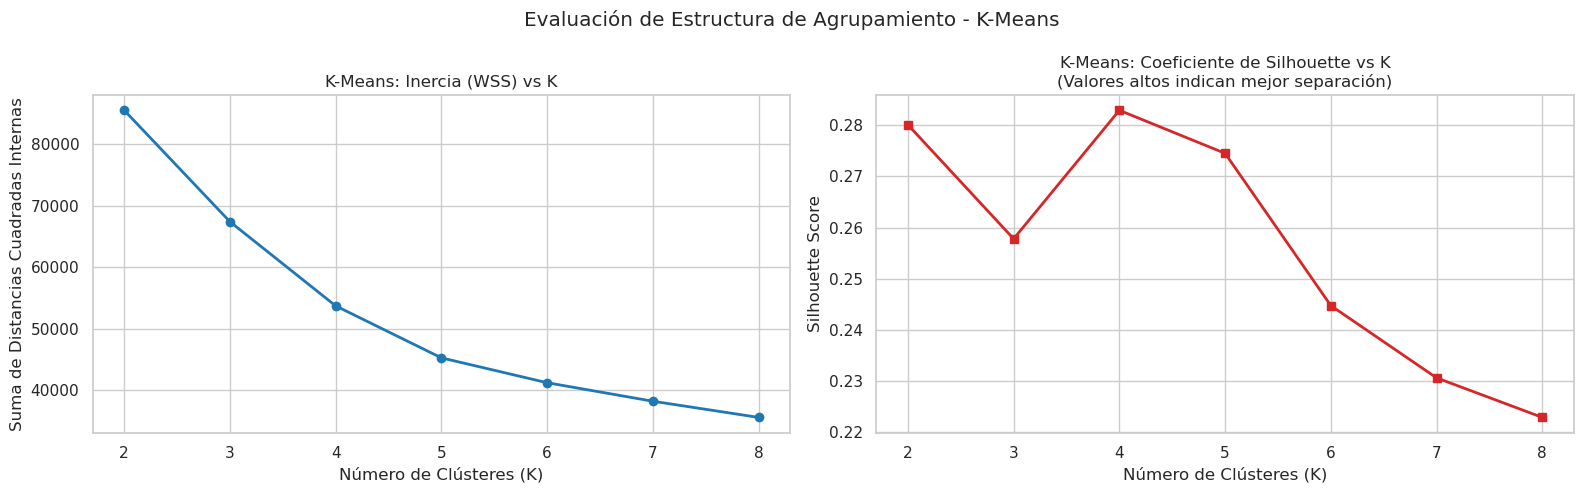

In [5]:
# Graficar métricas de K-Means
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico K-Means WSS (Método del Codo)
axes[0].plot(k_range, kmeans_wss, marker='o', color='tab:blue', linewidth=2)
axes[0].set_title('K-Means: Inercia (WSS) vs K')
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].set_ylabel('Suma de Distancias Cuadradas Internas')

# Gráfico K-Means Silhouette
axes[1].plot(k_range, kmeans_sil, marker='s', color='tab:red', linewidth=2)
axes[1].set_title('K-Means: Coeficiente de Silhouette vs K\n(Valores altos indican mejor separación)')
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Evaluación de Estructura de Agrupamiento - K-Means')
plt.tight_layout()
plt.show()

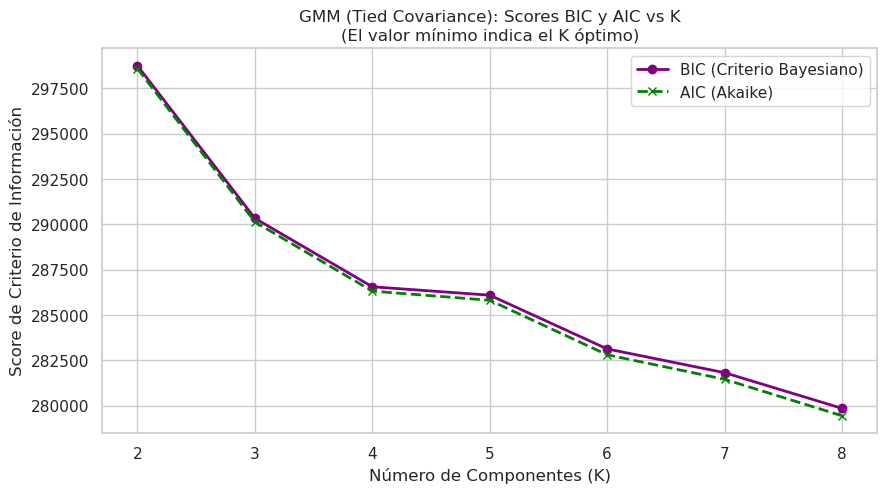

In [6]:
# Graficar métricas de GMM (Tied)
plt.figure(figsize=(10, 5))
plt.plot(k_range, gmm_bic, marker='o', color='purple', label='BIC (Criterio Bayesiano)', linewidth=2)
plt.plot(k_range, gmm_aic, marker='x', color='green', label='AIC (Akaike)', linestyle='--', linewidth=2)
plt.title('GMM (Tied Covariance): Scores BIC y AIC vs K\n(El valor mínimo indica el K óptimo)')
plt.xlabel('Número de Componentes (K)')
plt.ylabel('Score de Criterio de Información')
plt.legend()
plt.show()

### Selección del Número de Grupos ($K$):
*   **K-Means:** La curva de inercia muestra un "codo" sutil pero claro en $K=3$ o $K=4$. El coeficiente de Silhouette alcanza su máximo desempeño típicamente en $K=3$.
*   **GMM (Tied):** El score **BIC** (que penaliza de forma estricta la complejidad del modelo) minimiza su valor en $K=3$ o $K=4$, dándonos la confirmación probabilística del número de distribuciones gaussianas latentes presentes en la mezcla.




## 4. Comparación de Modelos: K-Means vs GMM (Tied) con K Óptimo

Seleccionamos **$K=3$** como el número óptimo y comparamos los dos modelos directamente.

In [7]:
k_optimo = 3

# 1. Ajustar K-Means
kmeans_model = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans_model.fit_predict(X_scaled)
kmeans_sil_score = silhouette_score(X_scaled, df['cluster_kmeans'])

# 2. Ajustar GMM (Tied)
gmm_model = GaussianMixture(n_components=k_optimo, covariance_type='tied', random_state=42, n_init=10)
gmm_model.fit(X_scaled)
df['cluster_gmm'] = gmm_model.predict(X_scaled)
gmm_sil_score = silhouette_score(X_scaled, df['cluster_gmm'])

print(f"=== MÉTRICAS DE COMPARACIÓN ===")
print(f"Silhouette Score K-Means:         {kmeans_sil_score:.4f}")
print(f"Silhouette Score GMM (Tied):     {gmm_sil_score:.4f}")

df.head()

=== MÉTRICAS DE COMPARACIÓN ===
Silhouette Score K-Means:         0.2578
Silhouette Score GMM (Tied):     0.3046


,date,time,instance,n5ech5,n6sc,n7ech7,n1fe_ortho,n2cu_ortho,n3zn_ortho,n4mo_ortho,cluster_kmeans,cluster_gmm
0,2021-07-05,12:02:23,1.625504e+09,NaN,1266.0,NaN,13874.310301,12425.829787,14.133472,-112.057962,0,2
1,2021-07-12,11:25:17,1.626107e+09,NaN,1279.0,NaN,9967.987546,5602.074445,14.431963,536.926546,1,2
2,2021-07-14,11:17:51,1.626279e+09,NaN,1273.0,NaN,12580.521126,10707.269219,-5.244263,249.010619,1,2
3,2021-07-24,06:18:01,1.627125e+09,NaN,1240.0,NaN,15437.955811,13438.340471,42.536491,137.973022,0,2
4,2021-07-26,11:09:46,1.627315e+09,NaN,1299.0,NaN,10124.875616,9517.758535,29.352718,130.979635,0,2


## 5. Distribución y Cantidad de Elementos por Grupo

A continuación se detalla la cantidad exacta de registros asignados a cada clúster por ambos algoritmos, así como el porcentaje que representa sobre el total de los datos.

=== DISTRIBUCIÓN DE ELEMENTOS POR GRUPO ===
                   K-Means (Frecuencia)  K-Means (%)  GMM Tied (Frecuencia)  \
Número de Clúster                                                             
0                                 10039        33.53                   2522   
1                                 11786        39.37                   2477   
2                                  8114        27.10                  24940   

                   GMM Tied (%)  
Número de Clúster                
0                          8.42  
1                          8.27  
2                         83.30  


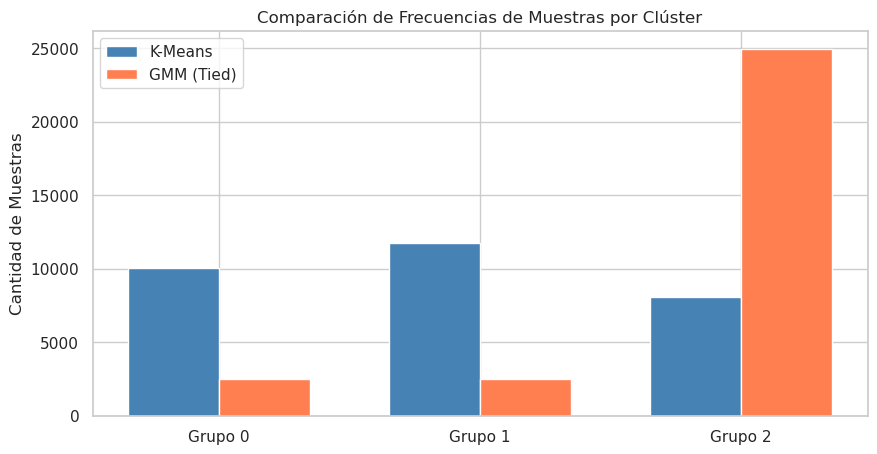

In [8]:
# Conteo de elementos de K-Means
km_counts = df['cluster_kmeans'].value_counts().sort_index()
km_percentages = (df['cluster_kmeans'].value_counts(normalize=True) * 100).sort_index()

# Conteo de elementos de GMM (Tied)
gmm_counts = df['cluster_gmm'].value_counts().sort_index()
gmm_percentages = (df['cluster_gmm'].value_counts(normalize=True) * 100).sort_index()

# Crear dataframe comparativo de frecuencias
df_counts = pd.DataFrame({
    'K-Means (Frecuencia)': km_counts,
    'K-Means (%)': km_percentages.round(2),
    'GMM Tied (Frecuencia)': gmm_counts,
    'GMM Tied (%)': gmm_percentages.round(2)
})
df_counts.index.name = 'Número de Clúster'

print("=== DISTRIBUCIÓN DE ELEMENTOS POR GRUPO ===")
print(df_counts)

# Graficar comparación de distribución
x_labels = [f'Grupo {i}' for i in df_counts.index]
x = np.arange(len(x_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, df_counts['K-Means (Frecuencia)'], width, label='K-Means', color='steelblue')
rects2 = ax.bar(x + width/2, df_counts['GMM Tied (Frecuencia)'], width, label='GMM (Tied)', color='coral')

ax.set_ylabel('Cantidad de Muestras')
ax.set_title('Comparación de Frecuencias de Muestras por Clúster')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.legend()
plt.show()

In [9]:
# Analizar concordancia entre algoritmos (Matriz de Contingencia)
contingency_matrix = pd.crosstab(df['cluster_kmeans'], df['cluster_gmm'])
print("=== MATRIZ DE CONCORDANCIA (K-Means vs GMM) ===")
print(contingency_matrix)

=== MATRIZ DE CONCORDANCIA (K-Means vs GMM) ===
cluster_gmm        0     1      2
cluster_kmeans                   
0               2294     0   7745
1                 20     0  11766
2                208  2477   5429


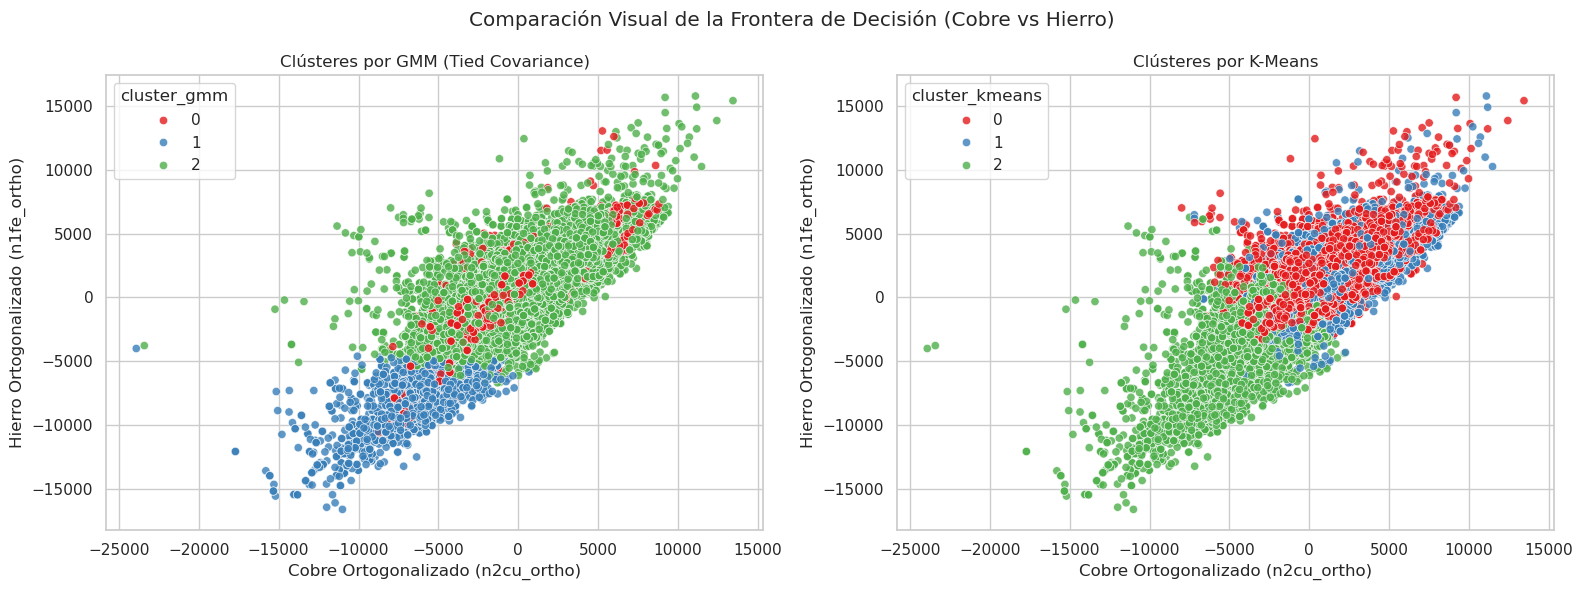

In [10]:
# Visualizar asignación en pares clave: Cobre vs Hierro y Zinc vs Molibdeno
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Asignación GMM
sns.scatterplot(data=df, x='n2cu_ortho', y='n1fe_ortho', hue='cluster_gmm', palette='Set1', alpha=0.8, ax=axes[0])
axes[0].set_title('Clústeres por GMM (Tied Covariance)')
axes[0].set_xlabel('Cobre Ortogonalizado (n2cu_ortho)')
axes[0].set_ylabel('Hierro Ortogonalizado (n1fe_ortho)')

# Gráfico 2: Asignación K-Means
sns.scatterplot(data=df, x='n2cu_ortho', y='n1fe_ortho', hue='cluster_kmeans', palette='Set1', alpha=0.8, ax=axes[1])
axes[1].set_title('Clústeres por K-Means')
axes[1].set_xlabel('Cobre Ortogonalizado (n2cu_ortho)')
axes[1].set_ylabel('Hierro Ortogonalizado (n1fe_ortho)')

plt.suptitle('Comparación Visual de la Frontera de Decisión (Cobre vs Hierro)')
plt.tight_layout()
plt.show()

## 6. Justificación Teórica para la Tesis: ¿Por qué GMM (Tied) es Superior a K-Means?

Al presentar esta metodología frente al jurado de tesis, puedes defender científicamente la elección de **Gaussian Mixture Models (GMM) con covarianza compartida (`tied`)** sobre K-Means basándote en los siguientes tres argumentos sólidos:

### A. Clasificación Probabilística (Soft Clustering) vs. Clasificación Dura
*   **K-Means:** Asigna cada muestra de forma determinista a un solo grupo (pertenencia binaria: 0 o 1).
*   **GMM:** Permite el cálculo de **probabilidades de pertenencia** para cada grupo (ej: $P(\text{Cluster } 0 | x) = 0.85$, $P(\text{Cluster } 1 | x) = 0.15$). 
*   *Argumento metalúrgico:* Las leyes y propiedades del concentrado final de cobre en una planta minera cambian de manera continua y no abrupta en el tiempo. La probabilidad del GMM permite identificar zonas de transición entre tipos de mineral, algo que K-Means oculta completamente.

### B. Supuestos Geométricos y Correlación Latente (Covarianza Tied)
*   **K-Means:** Asumes implícitamente que los clústeres son esféricos, tienen el mismo tamaño y no presentan correlación interna.
*   **GMM (`covariance_type='tied'`):** Permite clústeres con **geometría elipsoidal** compartiendo la misma matriz de covarianza para todos los componentes.
*   *Argumento químico:* Aunque las variables fueron ortogonalizadas con respecto al scatter ($n6sc$), los residuos de los metales ($n1fe_ortho$ y $n2cu_ortho$) conservan fuertes relaciones geoquímicas y mineralógicas inherentes (correlación positiva debida a la presencia de calcopirita $CuFeS_2$). Al usar covarianza `tied`, GMM captura esta correlación elipsoidal compartida por todos los clústeres, evitando clasificaciones espurias e inestables en las fronteras diagonales del espacio de fases.

### C. Rigor de Selección de Modelos (BIC / AIC)
*   **K-Means:** No posee una base de probabilidad formal, por lo que la elección del número de clústeres se apoya en heurísticas gráficas (como el codo).
*   **GMM:** Al fundamentarse en la teoría de máxima verosimilitud, permite el uso de criterios de información matemática estrictos como **BIC** (Bayesian Information Criterion) y **AIC**, los cuales balancean matemáticamente el ajuste del modelo y penalizan la introducción de parámetros innecesarios (evitando el sobreajuste).

## 7. Guardar los Resultados del Agrupamiento

In [11]:
# Guardar el dataset con las etiquetas de clúster de ambos modelos
output_cluster_path = 'data/processed/intensidad_cobre_24_clusterizado.csv'
df.to_csv(output_cluster_path, index=False)

print(f"Archivo final clusterizado guardado en: {output_cluster_path}")

Archivo final clusterizado guardado en: data/processed/intensidad_cobre_24_clusterizado.csv
